In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

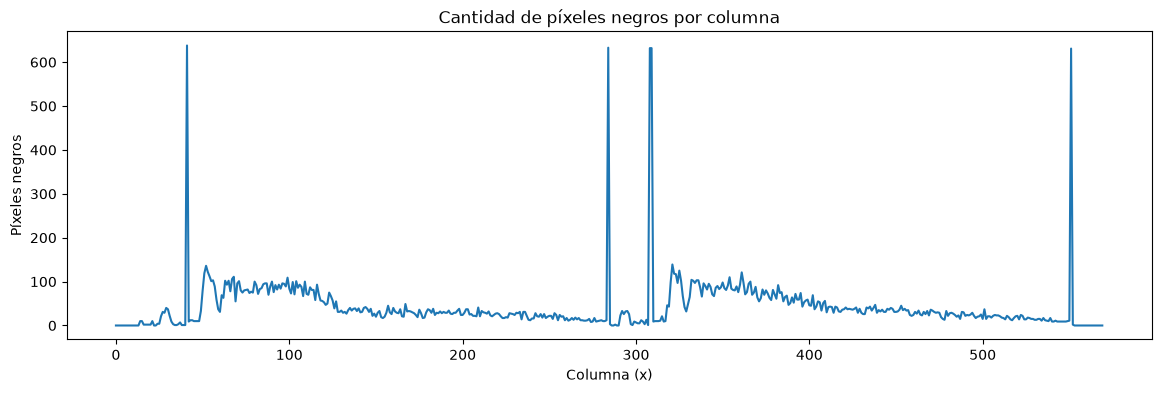

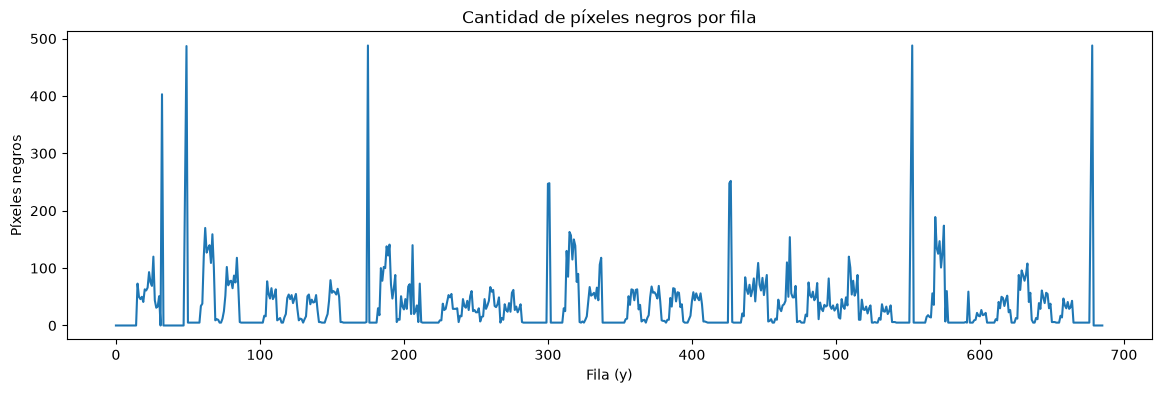

In [63]:
# Imagen binaria
ruta_imagen = '../images/raw/examen_1.png'
img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(
    img,
    127,
    255,
    cv2.THRESH_BINARY
)

# Proyecciones
proyeccion_x = np.sum(binary == 0, axis=0)
proyeccion_y = np.sum(binary == 0, axis=1)

# Proyección vertical
plt.figure(figsize=(14, 4))
plt.plot(proyeccion_x)
plt.title('Cantidad de píxeles negros por columna')
plt.xlabel('Columna (x)')
plt.ylabel('Píxeles negros')
plt.show()

# Proyección horizontal
plt.figure(figsize=(14, 4))
plt.plot(proyeccion_y)
plt.title('Cantidad de píxeles negros por fila')
plt.xlabel('Fila (y)')
plt.ylabel('Píxeles negros')
plt.show()

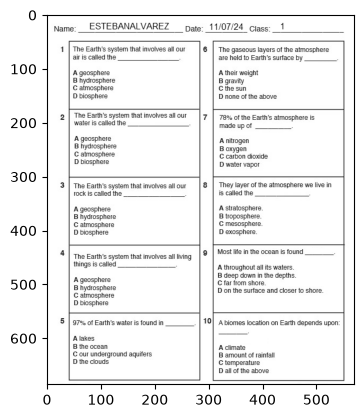

In [64]:
plt.imshow(img, cmap='gray', vmin=0, vmax=255)

In [65]:
# ==========================================
# 4. Detección de líneas de la plantilla
# ==========================================

# Binarización
_, binary = cv2.threshold(
    img,
    127,
    255,
    cv2.THRESH_BINARY
)

# Cantidad de píxeles negros por columna/fila
proyeccion_x = np.sum(binary == 0, axis=0)
proyeccion_y = np.sum(binary == 0, axis=1)

# Thresholds para detectar líneas
threshold_x = 200
threshold_y = 200

# Índices que corresponden a líneas verticales/horizontales
lineas_x = np.where(proyeccion_x >= threshold_x)[0]
lineas_y = np.where(proyeccion_y >= threshold_y)[0]


def agrupar_indices(indices):
    """Agrupa índices consecutivos en intervalos."""
    grupos = []

    if len(indices) == 0:
        return grupos

    inicio = indices[0]
    anterior = indices[0]

    for indice in indices[1:]:
        if indice == anterior + 1:
            anterior = indice
        else:
            grupos.append((inicio, anterior))
            inicio = indice
            anterior = indice

    grupos.append((inicio, anterior))

    return grupos


grupos_x = agrupar_indices(lineas_x)
grupos_y = agrupar_indices(lineas_y)

print("Líneas verticales:", grupos_x)
print("Líneas horizontales:", grupos_y)

Líneas verticales: [(np.int64(41), np.int64(41)), (np.int64(284), np.int64(284)), (np.int64(308), np.int64(309)), (np.int64(551), np.int64(551))]
Líneas horizontales: [(np.int64(32), np.int64(32)), (np.int64(48), np.int64(49)), (np.int64(175), np.int64(175)), (np.int64(300), np.int64(301)), (np.int64(426), np.int64(427)), (np.int64(552), np.int64(553)), (np.int64(677), np.int64(678))]


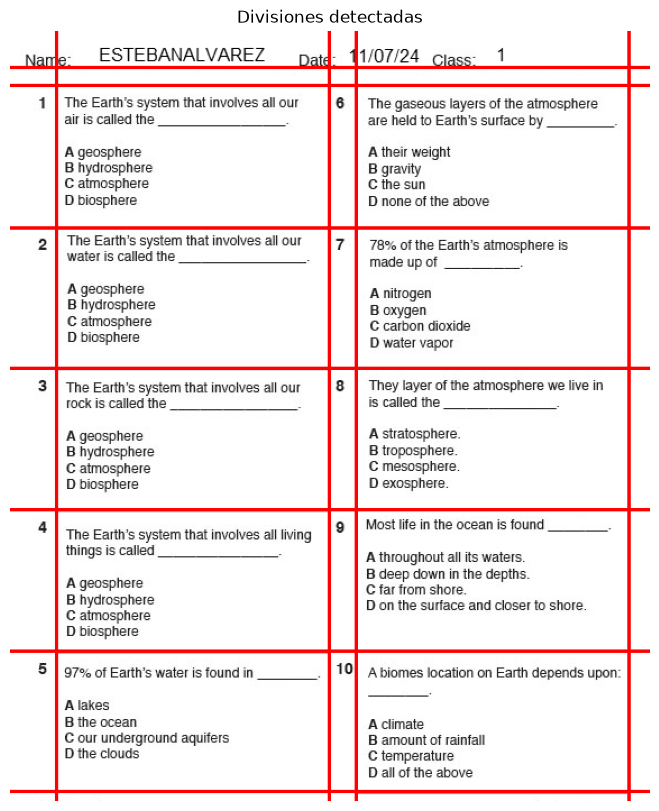

In [66]:
# ==========================================
# 5. Visualización de las divisiones detectadas
# ==========================================

img_divisiones = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Dibujar líneas verticales
for inicio, fin in grupos_x:
    x = int((inicio + fin) / 2)
    cv2.line(
        img_divisiones,
        (x, 0),
        (x, img.shape[0] - 1),
        (0, 0, 255),
        2
    )

# Dibujar líneas horizontales
for inicio, fin in grupos_y:
    y = int((inicio + fin) / 2)
    cv2.line(
        img_divisiones,
        (0, y),
        (img.shape[1] - 1, y),
        (0, 0, 255),
        2
    )

plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(img_divisiones, cv2.COLOR_BGR2RGB))
plt.title('Divisiones detectadas')
plt.axis('off')
plt.show()

In [67]:
x = [int((inicio + fin) / 2) for inicio, fin in grupos_x]
y = [int((inicio + fin) / 2) for inicio, fin in grupos_y[1:]]

print("Cortes verticales:", x)
print("Cortes horizontales:", y)

Cortes verticales: [41, 284, 308, 551]
Cortes horizontales: [48, 175, 300, 426, 552, 677]


In [68]:
def obtener_cuadrantes(img, grupos_x, grupos_y):
    cuadrantes = []

    for fila in range(5):
        for columna in range(2):

            if columna == 0:
                x_inicio = grupos_x[0][1] + 3
                x_fin = grupos_x[1][0] - 3
            else:
                x_inicio = grupos_x[2][1] + 3
                x_fin = grupos_x[3][0] - 3

            y_inicio = grupos_y[fila][1] + 3
            y_fin = grupos_y[fila + 1][0] - 3

            cuadrante = img[y_inicio:y_fin, x_inicio:x_fin]

            cuadrantes.append(cuadrante)

    return cuadrantes

In [69]:
cuadrantes = obtener_cuadrantes(img, grupos_x, grupos_y[1:])

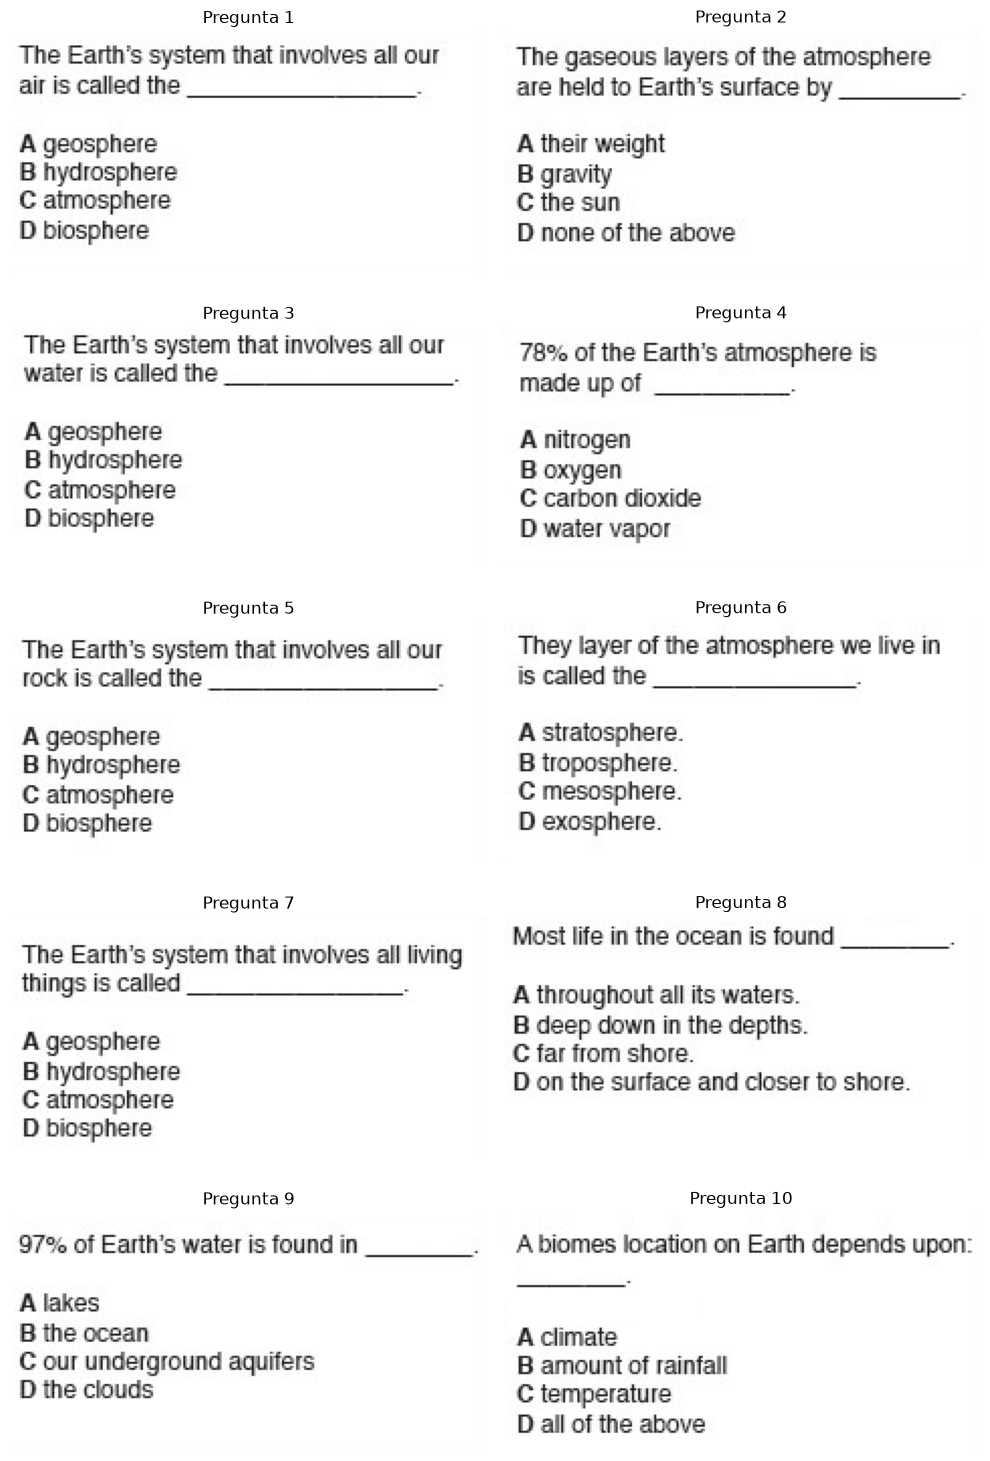

In [70]:
fig, axs = plt.subplots(5, 2, figsize=(10, 15))

for i, cuadrante in enumerate(cuadrantes):
    axs[i // 2, i % 2].imshow(
        cuadrante,
        cmap='gray',
        vmin=0,
        vmax=255
    )
    axs[i // 2, i % 2].set_title(f'Pregunta {i + 1}')
    axs[i // 2, i % 2].axis('off')

plt.tight_layout()
plt.show()

In [71]:
cuadrante = cuadrantes[5]

_, binaria = cv2.threshold(
    cuadrante,
    200,
    255,
    cv2.THRESH_BINARY
)

In [72]:
w = np.array([
    [-1, -1, -1, -1, -1, -1, -1, -1],
    [ 2,  2,  2,  2,  2,  2,  2,  2],
    [-1, -1, -1, -1, -1, -1, -1, -1]
])

filtrada = cv2.filter2D(
    binaria,
    cv2.CV_64F,
    w
)

filtrada_abs = abs(filtrada)    

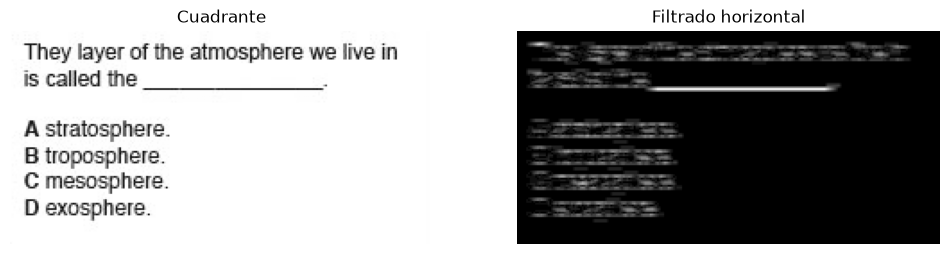

In [73]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cuadrante, cmap='gray')
plt.title('Cuadrante')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtrada_abs, cmap='gray')
plt.title('Filtrado horizontal')
plt.axis('off')

plt.show()

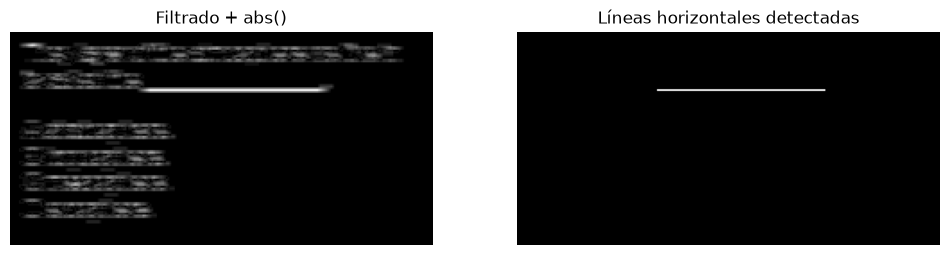

In [74]:
deteccion = filtrada_abs >= filtrada_abs.max() * 0.95

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(filtrada_abs, cmap='gray')
plt.title('Filtrado + abs()')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(deteccion, cmap='gray')
plt.title('Líneas horizontales detectadas')
plt.axis('off')

plt.show()

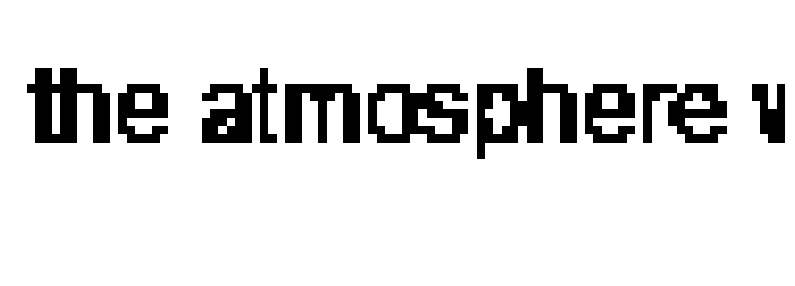

In [75]:
ys, xs = np.where(deteccion)

conteo_y = np.sum(deteccion, axis=1)
y_linea = np.argmax(conteo_y)

xs_linea = np.where(deteccion[y_linea])[0]

x_inicio_linea = xs_linea.min()
x_fin_linea = xs_linea.max()

# cuadrante = cuadrantes[8]

region_opciones = cuadrante[
    0:y_linea,
    x_inicio_linea:x_fin_linea
]

_, region_opciones_binaria = cv2.threshold(
    region_opciones,
    200,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(10, 5))
plt.imshow(region_opciones_binaria, cmap="gray")
plt.axis("off")
plt.show()

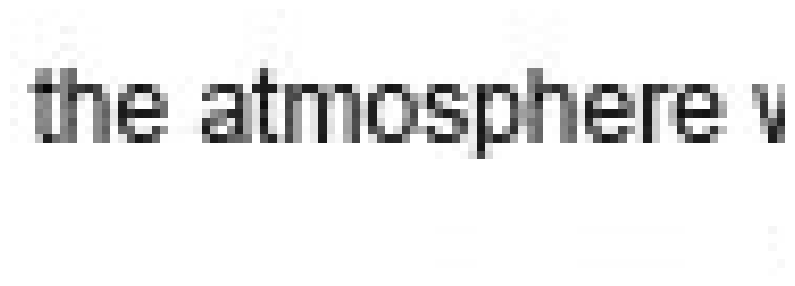

In [76]:
plt.figure(figsize=(10, 5))
plt.imshow(region_opciones, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

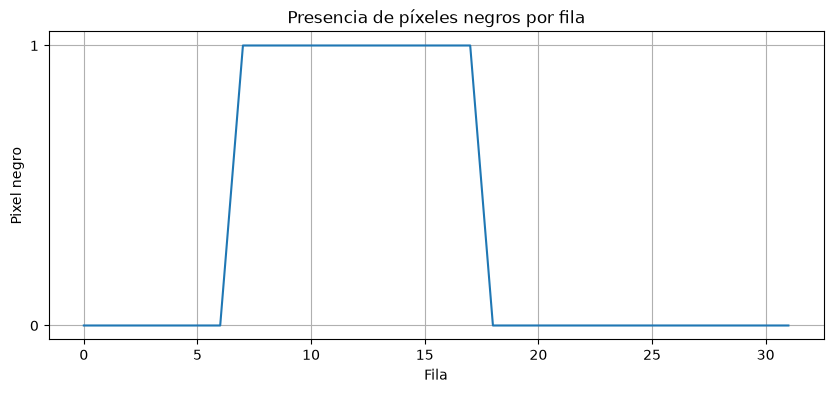

In [77]:
proyeccion_y = np.any(
    region_opciones_binaria == 0,
    axis=1
).astype(int)

plt.figure(figsize=(10, 4))
plt.plot(proyeccion_y)
plt.yticks([0, 1])
plt.xlabel("Fila")
plt.ylabel("Pixel negro")
plt.title("Presencia de píxeles negros por fila")
plt.grid()
plt.show()

In [78]:
_, binaria = cv2.threshold(
    region_opciones,
    200,
    255,
    cv2.THRESH_BINARY
)

proyeccion_x = np.max(binaria == 0, axis=0)
proyeccion_y = np.sum(binaria == 0, axis=1)

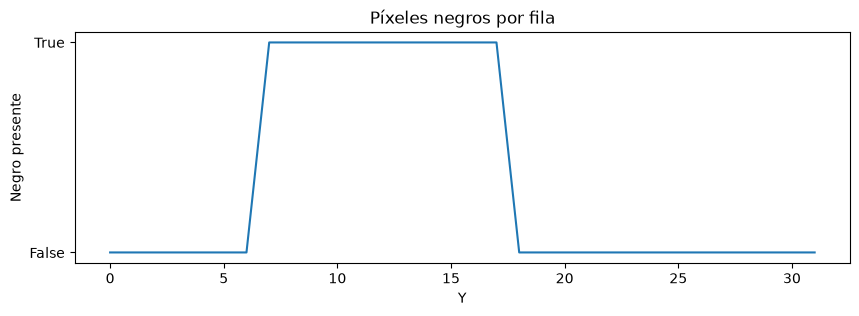

In [79]:
proyeccion_y = np.any(binaria == 0, axis=1)

plt.figure(figsize=(10, 3))
plt.plot(proyeccion_y)
plt.title("Píxeles negros por fila")
plt.xlabel("Y")
plt.ylabel("Negro presente")
plt.yticks([0, 1], ["False", "True"])
plt.show()

In [80]:
indices_negros = np.where(proyeccion_y)[0]

grupos_renglones = agrupar_indices(indices_negros)

ultimo_renglon = grupos_renglones[-1]

y_inicio = ultimo_renglon[0]
y_fin = ultimo_renglon[1]

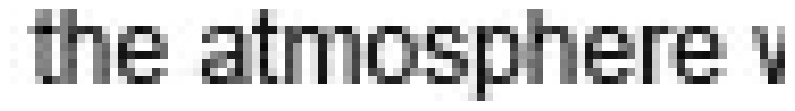

In [81]:
ultimo_renglon = grupos_renglones[-1]

y_inicio = ultimo_renglon[0]
y_fin = ultimo_renglon[1]

respuesta = region_opciones[y_inicio:y_fin + 1, :]

plt.figure(figsize=(10, 2))
plt.imshow(respuesta, cmap="gray")
plt.axis("off")
plt.show()

In [82]:
def obtener_respuesta(cuadrante):

    # Binarización
    _, binaria = cv2.threshold(
        cuadrante,
        200,
        255,
        cv2.THRESH_BINARY
    )

    # Detección de la línea horizontal
    w = np.array([
        [-1, -1, -1],
        [ 2,  2,  2],
        [-1, -1, -1]
    ])

    filtrada = cv2.filter2D(
        binaria,
        cv2.CV_64F,
        w
    )

    filtrada_abs = abs(filtrada)

    deteccion = filtrada_abs >= filtrada_abs.max() * 0.9

    # Coordenada Y de la línea
    conteo_y = np.sum(deteccion, axis=1)
    y_linea = np.argmax(conteo_y)

    # Extremos X de la línea
    xs_linea = np.where(deteccion[y_linea])[0]

    x_inicio_linea = xs_linea.min()
    x_fin_linea = xs_linea.max()

    # Recortar región superior a la línea
    region_opciones = cuadrante[
        0:y_linea,
        x_inicio_linea:x_fin_linea
    ]

    # Binarizar región
    _, binaria_opciones = cv2.threshold(
        region_opciones,
        200,
        255,
        cv2.THRESH_BINARY
    )

    # Revisar las últimas 20 filas
    ultimas_filas = binaria_opciones[-14:, :]

    hay_pixel_negro = np.any(ultimas_filas == 0)

    # Si no hay ningún píxel negro, no hay respuesta
    if not hay_pixel_negro:
        return None

    # Detectar filas con al menos un píxel negro
    proyeccion_y = np.any(
        binaria_opciones == 0,
        axis=1
    )

    indices_negros = np.where(proyeccion_y)[0]

    grupos_renglones = agrupar_indices(indices_negros)

    if len(grupos_renglones) == 0:
        return None

    ultimo_renglon = grupos_renglones[-1]

    y_inicio = ultimo_renglon[0]
    y_fin = ultimo_renglon[1]

    respuesta = region_opciones[
        y_inicio:y_fin + 1,
        :
    ]

    return respuesta

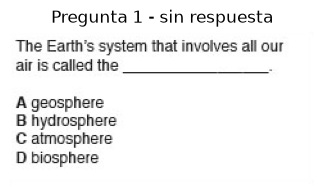

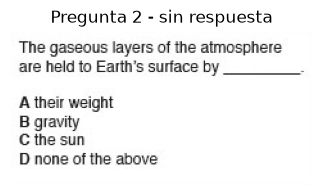

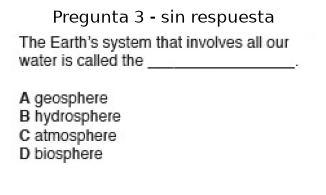

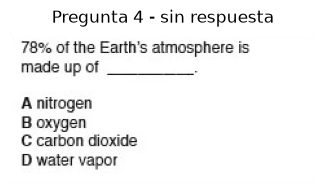

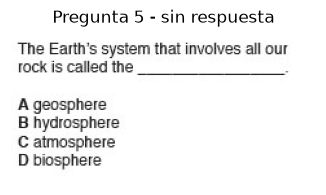

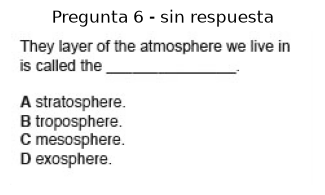

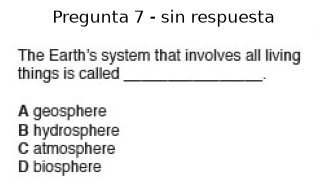

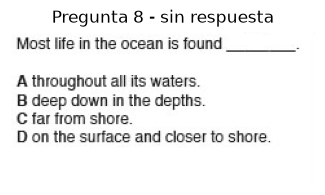

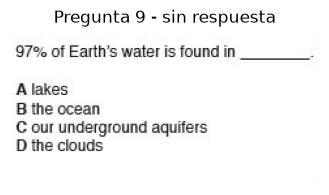

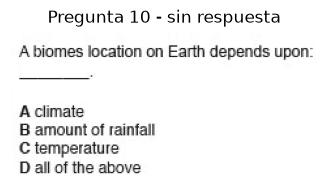

In [83]:
respuestas = []

for i, cuadrante in enumerate(cuadrantes):

    respuesta = obtener_respuesta(cuadrante)
    respuestas.append(respuesta)

    plt.figure(figsize=(10, 2))

    if respuesta is not None:
        plt.imshow(respuesta, cmap="gray")
        plt.title(f"Pregunta {i + 1} - respuesta detectada")
    else:
        plt.imshow(cuadrante, cmap="gray")
        plt.title(f"Pregunta {i + 1} - sin respuesta")

    plt.axis("off")
    plt.show()